# Script to estimate airborne fraction trends with all LULC measurement

combinations

Fossil emissions and atmospheric growth from GCB 2025 with LULC panel measurements

[J. Eduardo Vera-Valdés](https://everval.github.io) [](https://orcid.org/0000-0002-0337-8055) (Aalborg University, CoRE)

## Script to run the mixes model analysis

Load the dataset and the LULC measurement panel.

In [1]:
#| warning: false
#| message: false
#| output: false
cd(@__DIR__)
using Pkg
Pkg.activate(pwd())

using CSV
using DataFrames
using Statistics
include(joinpath(@__DIR__, "estimation_functions.jl"))

dataframe_to_markdown_table (generic function with 1 method)

In [1]:
data_path = joinpath(@__DIR__, "..", "data", "Data_GCB_2025_cols.csv")
lulc_path = joinpath(@__DIR__, "..", "results", "LULC_measurements_extracted_and_derived.csv")

gcb_df = CSV.read(data_path, DataFrame)
lulc_df = CSV.read(lulc_path, DataFrame)
rename!(lulc_df, :year => :Year);

## Full sample

### Build the airborne-fraction series

Transform to panel format and compute the AF series for each LULC measurement combination.

In [1]:
long_df = build_panel_dataset(gcb_df, lulc_df)

### Fit the mixed model

In [1]:
mmodel = fit_mixed_model(long_df)

  ------------- -------- -------- ------- --------- --------------
                    Est.       SE       z         p   σ_definition
  (Intercept)     0.4070   0.0056   73.02   \<1e-99         0.0352
  t               0.0011   0.0001   10.80   \<1e-26         0.0003
  Residual        0.1237                            
  ------------- -------- -------- ------- --------- --------------


Report the results of the mixed model estimation.

In [1]:
group_df = extract_group_coefficients(mmodel, long_df)

In [1]:
summary_df = summarize_population_effects(mmodel, group_df)

### Plotting the mixed model results


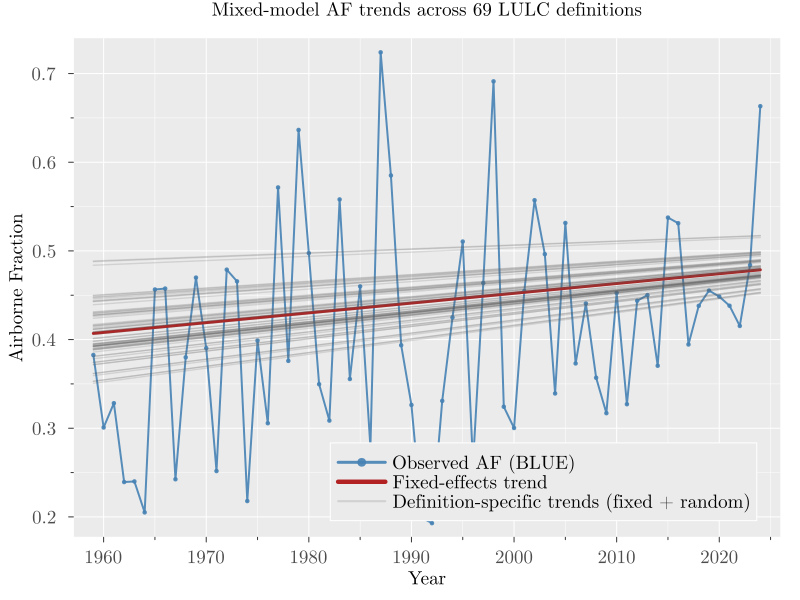

In [1]:
using Plots.PlotMeasures
years = sort(unique(long_df.Year))
t_vals = years .- minimum(years)

# Choose one observed AF definition to overlay for perspective.
overlay_def = first(group_df.definition)
overlay_df = long_df[long_df.definition .== overlay_def, [:Year, :AF]]

p_mm = plot(
    title = "Mixed-model AF trends across 69 LULC definitions",
    xlabel = "Year",
    ylabel = "Airborne Fraction",
    size = (800, 600),
    margin = 3mm,
    legend = :topleft,
)


# Overlay one observed AF series for context.
plot!(
    p_mm,
    overlay_df.Year,
    overlay_df.AF;
    color = :steelblue,
    linewidth = 2.0,
    linestyle = :solid,
    marker = :circle,
    markersize = 2.5,
    alpha = 0.9,
    label = "Observed AF ($(overlay_def))",
)

# Plot fixed-effects trend as a solid highlighted line.
yhat_fixed = summary_df.mu_alpha[1] .+ summary_df.mu_beta[1] .* t_vals
plot!(
    p_mm,
    years,
    yhat_fixed;
    color = :firebrick,
    linewidth = 3.0,
    linestyle = :solid,
    label = "Fixed-effects trend",
    legend = :bottomright
)

# Plot 69 definition-specific lines: fixed + random effects (translucent).
for (j, r) in enumerate(eachrow(group_df))
    alpha_j = r.alpha_j
    beta_j = r.beta_j
    yhat_j = alpha_j .+ beta_j .* t_vals
    plot!(
        p_mm,
        years,
        yhat_j;
        color = :gray35,
        alpha = 0.18,
        linewidth = 1.4,
        linestyle = :solid,
        label = (j == 1 ? "Definition-specific trends (fixed + random)" : nothing),
    )
end

p_mm

Save the mixed model plot.

In [1]:
savefig(p_mm, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends_robustness.png"))
savefig(p_mm, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends_robustness.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_mixed_model_definition_trends_robustness.pdf"

## Subsample up to 2023

In [1]:
long_df_2023 = filter(row -> row.Year <= 2023, long_df)

Fit the mixed model to the subsample.

In [1]:
mmodel_2023 = fit_mixed_model(long_df_2023)

  ------------- -------- -------- ------- --------- --------------
                    Est.       SE       z         p   σ_definition
  (Intercept)     0.4133   0.0056   73.98   \<1e-99         0.0355
  t               0.0008   0.0001    7.82   \<1e-14         0.0003
  Residual        0.1218                            
  ------------- -------- -------- ------- --------- --------------


Report the results of the mixed model estimation for the subsample.

In [1]:
group_df_2023 = extract_group_coefficients(mmodel_2023, long_df_2023)
summary_df_2023 = summarize_population_effects(mmodel_2023, group_df_2023)

Plot the mixed model results for the subsample.


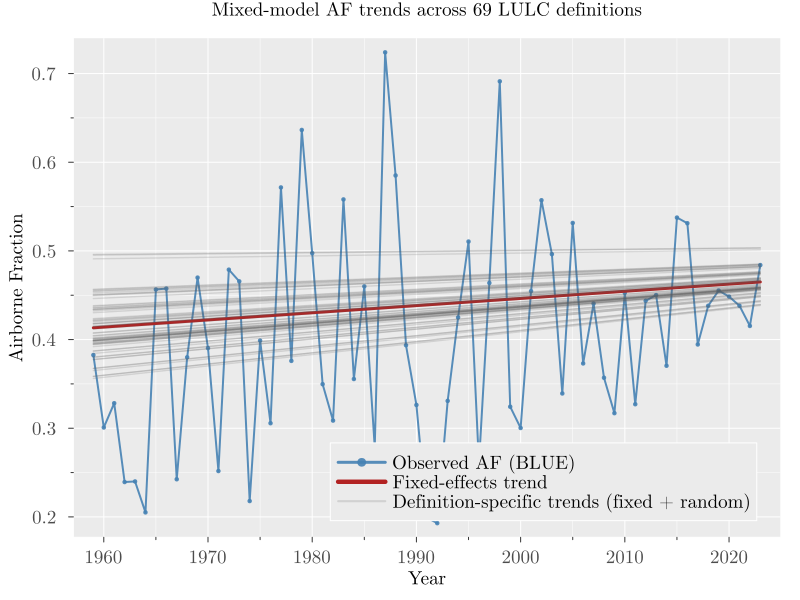

In [1]:
years_2023 = sort(unique(long_df_2023.Year))
t_vals = years_2023 .- minimum(years_2023)

# Choose one observed AF definition to overlay for perspective.
overlay_def = first(group_df_2023.definition)
overlay_df = long_df_2023[long_df_2023.definition .== overlay_def, [:Year, :AF]]

p_mm_2023 = plot(
    title = "Mixed-model AF trends across 69 LULC definitions",
    xlabel = "Year",
    ylabel = "Airborne Fraction",
    size = (800, 600),
    margin = 3mm,
    legend = :topleft,
)


# Overlay one observed AF series for context.
plot!(
    p_mm_2023,
    overlay_df.Year,
    overlay_df.AF;
    color = :steelblue,
    linewidth = 2.0,
    linestyle = :solid,
    marker = :circle,
    markersize = 2.5,
    alpha = 0.9,
    label = "Observed AF ($(overlay_def))",
)

# Plot fixed-effects trend as a solid highlighted line.
yhat_fixed = summary_df_2023.mu_alpha[1] .+ summary_df_2023.mu_beta[1] .* t_vals
plot!(
    p_mm_2023,
    years_2023,
    yhat_fixed;
    color = :firebrick,
    linewidth = 3.0,
    linestyle = :solid,
    label = "Fixed-effects trend",
    legend = :bottomright
)

# Plot 69 definition-specific lines: fixed + random effects (translucent).
for (j, r) in enumerate(eachrow(group_df_2023))
    alpha_j = r.alpha_j
    beta_j = r.beta_j
    yhat_j = alpha_j .+ beta_j .* t_vals
    plot!(
        p_mm_2023,
        years_2023,
        yhat_j;
        color = :gray35,
        alpha = 0.18,
        linewidth = 1.4,
        linestyle = :solid,
        label = (j == 1 ? "Definition-specific trends (fixed + random)" : nothing),
    )
end

p_mm_2023

In [1]:
savefig(p_mm_2023, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends_up_to_2023_robustness.png"))
savefig(p_mm_2023, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends_up_to_2023_robustness.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_mixed_model_definition_trends_up_to_2023_robustness.pdf"

## Results

### Fixed-effects summary (mixed models)

In [1]:
#| results: asis
mixed_results_table = build_mixed_fixed_effects_summary_table(mmodel, long_df, mmodel_2023, long_df_2023)
mixed_table_md = dataframe_to_markdown_table(mixed_results_table)

println(mixed_table_md)

mixed_out_path = joinpath(@__DIR__, "..", "results", "af_raw_mixed_model_fixed_effects_summary_table.md")
open(mixed_out_path, "w") do io
    write(io, mixed_table_md)
end

println("Saved mixed-model summary table to: $(mixed_out_path)")

| Metric | Intercept (full) | Slope (full) | Intercept (up to 2023) | Slope (up to 2023) |
|---|---:|---:|---:|---:|
| Estimate | 0.406959 | 0.001103 | 0.41326 | 0.000808 |
| Standard error | 0.005573 | 0.000102 | 0.005586 | 0.000103 |
| p-value | 0.0 | 0.0 | 0.0 | 0.0 |
| R-squared (marginal) | 0.027148 | 0.027148 | 0.014722 | 0.014722 |
| R-squared (conditional) | 0.059454 | 0.059454 | 0.049017 | 0.049017 |

Saved mixed-model summary table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_raw_mixed_model_fixed_effects_summary_table.md

## Mixed model with AR1 component (R)

### Full sample and up to 2023

In [1]:
Pkg.add("RCall")
using RCall

@rput long_df long_df_2023

In [1]:
R"""
library(nlme)

if (!requireNamespace("performance", quietly = TRUE)) {
    install.packages("performance", repos = "https://cloud.r-project.org")
}

extract_ar1_stats <- function(model_ar1) {
    phi <- as.numeric(coef(model_ar1$modelStruct$corStruct, unconstrained = FALSE))

    se_phi <- NA_real_
    ap <- model_ar1$apVar
    if (is.matrix(ap)) {
        nms <- colnames(ap)
        idx <- which(nms %in% c("corStruct", "Phi", "phi"))
        if (length(idx) > 0) {
            se_all <- sqrt(diag(ap))
            se_phi <- as.numeric(se_all[idx[1]])
        }
    }

    p_phi <- NA_real_
    if (!is.na(se_phi) && is.finite(se_phi) && se_phi > 0) {
        z_phi <- phi / se_phi
        p_phi <- 2 * pnorm(-abs(z_phi))
    }

    data.frame(
        ar1_estimate = phi,
        ar1_se = se_phi,
        ar1_pvalue = p_phi
    )
}

fit_ar1_bundle <- function(df) {
    df$definition <- as.factor(df$definition)
    df$t <- df$Year - min(df$Year)

    ctrl <- lmeControl(
        opt = "optim",
        msMaxIter = 500,
        maxIter = 200,
        niterEM = 80,
        tolerance = 1e-6,
        msVerbose = FALSE,
        returnObject = TRUE
    )

    model_ar1 <- lme(
        AF ~ t,
        random = ~ t | definition,
        correlation = corAR1(form = ~ t | definition),
        data = df,
        method = "REML",
        control = ctrl
    )

    t_ar1 <- summary(model_ar1)$tTable
    r2_ar1 <- suppressWarnings(performance::r2_nakagawa(model_ar1))

    fixed_stats <- data.frame(
        alpha = unname(fixef(model_ar1)[1]),
        alpha_se = unname(t_ar1["(Intercept)", "Std.Error"]),
        alpha_pvalue = unname(t_ar1["(Intercept)", "p-value"]),
        beta = unname(fixef(model_ar1)[2]),
        beta_se = unname(t_ar1["t", "Std.Error"]),
        beta_pvalue = unname(t_ar1["t", "p-value"]),
        r_squared_marginal = as.numeric(r2_ar1$R2_marginal),
        r_squared_conditional = as.numeric(r2_ar1$R2_conditional)
    )

    list(
        model = model_ar1,
        fixed = fixed_stats,
        ar1 = extract_ar1_stats(model_ar1),
        resid = as.numeric(residuals(model_ar1, type = "normalized"))
    )
}

ar1_full <- fit_ar1_bundle(long_df)
ar1_2023 <- fit_ar1_bundle(long_df_2023)

ar1_fixed_full <- ar1_full$fixed
ar1_fixed_2023 <- ar1_2023$fixed
ar1_stats_full <- ar1_full$ar1
ar1_stats_2023 <- ar1_2023$ar1
resid_ar1 <- ar1_full$resid

print(summary(ar1_full$model))
print(ar1_stats_full)
print(summary(ar1_2023$model))
print(ar1_stats_2023)
"""

Linear mixed-effects model fit by REML
  Data: df 
        AIC     BIC   logLik
  -5989.063 -5944.1 3001.531

Random effects:
 Formula: ~t | definition
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev       Corr  
(Intercept) 0.0345555468 (Intr)
t           0.0002886056 -0.967
Residual    0.1238748141       

Correlation Structure: AR(1)
 Formula: ~t | definition 
 Parameter estimate(s):
       Phi 
0.06301149 
Fixed effects:  AF ~ t 
                Value   Std.Error   DF  t-value p-value
(Intercept) 0.4067841 0.005672633 4484 71.70992       0
t           0.0011170 0.000108058 4484 10.33662       0
 Correlation: 
  (Intr)
t -0.783

Standardized Within-Group Residuals:
        Min          Q1         Med          Q3         Max 
-2.17935905 -0.77777975 -0.06416635  0.65587134  3.38950521 

Number of Observations: 4554
Number of Groups: 69 
  ar1_estimate     ar1_se ar1_pvalue
1   0.06301149 0.03073133 0.04032553
Linear mixed-effects model fit by RE

RObject{VecSxp}
  ar1_estimate     ar1_se ar1_pvalue
1   0.05640585 0.02982834 0.05862229

In [1]:
@rget ar1_fixed_full ar1_fixed_2023 ar1_stats_full ar1_stats_2023 resid_ar1

ar1_fixed_full
ar1_stats_full
ar1_fixed_2023
ar1_stats_2023

### AR1-augmented fixed-effects summary table

In [1]:
#| results: asis
# Build a mixed-model summary table that mirrors the existing format and adds
# AR1 coefficient columns for both estimation windows.
ar1_augmented_table = DataFrame(
    Metric = [
        "Estimate",
        "Standard error",
        "p-value",
        "R-squared (marginal)",
        "R-squared (conditional)",
    ],
    Intercept_full = [
        ar1_fixed_full.alpha[1],
        ar1_fixed_full.alpha_se[1],
        ar1_fixed_full.alpha_pvalue[1],
        ar1_fixed_full.r_squared_marginal[1],
        ar1_fixed_full.r_squared_conditional[1],
    ],
    Slope_full = [
        ar1_fixed_full.beta[1],
        ar1_fixed_full.beta_se[1],
        ar1_fixed_full.beta_pvalue[1],
        ar1_fixed_full.r_squared_marginal[1],
        ar1_fixed_full.r_squared_conditional[1],
    ],
    AR1_full = [
        ar1_stats_full.ar1_estimate[1],
        ar1_stats_full.ar1_se[1],
        ar1_stats_full.ar1_pvalue[1],
        missing,
        missing,
    ],
    Intercept_up_to_2023 = [
        ar1_fixed_2023.alpha[1],
        ar1_fixed_2023.alpha_se[1],
        ar1_fixed_2023.alpha_pvalue[1],
        ar1_fixed_2023.r_squared_marginal[1],
        ar1_fixed_2023.r_squared_conditional[1],
    ],
    Slope_up_to_2023 = [
        ar1_fixed_2023.beta[1],
        ar1_fixed_2023.beta_se[1],
        ar1_fixed_2023.beta_pvalue[1],
        ar1_fixed_2023.r_squared_marginal[1],
        ar1_fixed_2023.r_squared_conditional[1],
    ],
    AR1_up_to_2023 = [
        ar1_stats_2023.ar1_estimate[1],
        ar1_stats_2023.ar1_se[1],
        ar1_stats_2023.ar1_pvalue[1],
        missing,
        missing,
    ],
)

fmt_cell(x) = ismissing(x) ? "" : string(round(x; digits = 6))

header_ar1 = "| Metric | Intercept (full) | Slope (full) | AR1 (full) | Intercept (up to 2023) | Slope (up to 2023) | AR1 (up to 2023) |"
sep_ar1 = "|---|---:|---:|---:|---:|---:|---:|"

rows_ar1 = String[]
for r in eachrow(ar1_augmented_table)
    push!(rows_ar1, "| $(r.Metric) | $(fmt_cell(r.Intercept_full)) | $(fmt_cell(r.Slope_full)) | $(fmt_cell(r.AR1_full)) | $(fmt_cell(r.Intercept_up_to_2023)) | $(fmt_cell(r.Slope_up_to_2023)) | $(fmt_cell(r.AR1_up_to_2023)) |")
end

ar1_augmented_table_md = join([header_ar1, sep_ar1, rows_ar1...], "\n") * "\n"

println(ar1_augmented_table_md)

ar1_out_path = joinpath(@__DIR__, "..", "results", "af_raw_mixed_model_fixed_effects_summary_table_ar1.md")
open(ar1_out_path, "w") do io
    write(io, ar1_augmented_table_md)
end

println("Saved AR1-augmented mixed-model summary table to: $(ar1_out_path)")

| Metric | Intercept (full) | Slope (full) | AR1 (full) | Intercept (up to 2023) | Slope (up to 2023) | AR1 (up to 2023) |
|---|---:|---:|---:|---:|---:|---:|
| Estimate | 0.406784 | 0.001117 | 0.063011 | 0.413403 | 0.000806 | 0.056406 |
| Standard error | 0.005673 | 0.000108 | 0.030731 | 0.005677 | 0.000109 | 0.029828 |
| p-value | 0.0 | 0.0 | 0.040326 | 0.0 | 0.0 | 0.058622 |
| R-squared (marginal) | 0.027474 | 0.027474 |  | 0.014468 | 0.014468 |  |
| R-squared (conditional) | 0.069058 | 0.069058 |  | 0.058605 | 0.058605 |  |

Saved AR1-augmented mixed-model summary table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_raw_mixed_model_fixed_effects_summary_table_ar1.md